# Ensemble Models & Evaluation

**Level:** Intermediate  
**Goal:** Replace baseline models with ensemble methods and evaluate them properly.

We cover: Random Forest, Gradient Boosting, 5-fold cross-validation, ROC & Precision-Recall curves, and feature importance.

In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score,
    ConfusionMatrixDisplay, confusion_matrix
)
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 130
PALETTE = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0']
IMG = '../images/'
print('Libraries loaded.')

Libraries loaded.


In [2]:
# Load artifacts from notebook 1
with open('../data/nb1_artifacts.pkl', 'rb') as f:
    arts = pickle.load(f)

X_train  = arts['X_train']
X_test   = arts['X_test']
y_train  = arts['y_train']
y_test   = arts['y_test']
FEATURES = arts['FEATURES']

print(f'Train: {len(X_train):,}  |  Test: {len(X_test):,}')
print(f'Features: {FEATURES}')

Train: 77,176  |  Test: 19,294
Features: ['estimated_days', 'item_count', 'total_price', 'freight_value', 'product_weight_g', 'product_volume', 'payment_installments', 'same_state', 'purchase_dow', 'purchase_month', 'purchase_hour', 'payment_type', 'customer_state']


## 1. Why Ensemble Methods?

A single Decision Tree overfits to noise. Ensembles combine many trees:
- **Random Forest** — trains trees independently on random subsets, then averages (bagging)
- **Gradient Boosting** — trains trees sequentially, each one correcting the errors of the last (boosting)

**Why?** A single decision tree memorises training noise — it overfits. Ensembles reduce this by combining many trees, each trained on slightly different data or features. The intuition: a thousand imperfect judges who disagree with each other are collectively more accurate than one perfect-seeming judge.

## 2. Random Forest

**Why?** Random Forest trains each tree on a random bootstrap sample of rows *and* a random subset of features. The feature randomness is key — it forces trees to be different from each other, so their errors don't correlate. When you average uncorrelated errors, they cancel out.

In [3]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=20,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf   = rf.predict(X_test)
y_proba_rf  = rf.predict_proba(X_test)[:, 1]

print('=== Random Forest ===')
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_rf, target_names=['On Time','Late']))

=== Random Forest ===
              precision    recall  f1-score   support

     On Time       0.96      0.81      0.88     17729
        Late       0.21      0.59      0.31      1565

    accuracy                           0.79     19294
   macro avg       0.58      0.70      0.59     19294
weighted avg       0.90      0.79      0.83     19294



## 3. Gradient Boosting

**Why?** Where Random Forest builds trees independently and averages, Gradient Boosting builds them sequentially — each new tree fits the *residual errors* of all previous trees. It's more accurate on average but more sensitive to hyperparameters and slower to train. We use a low learning rate (0.05) to prevent any single tree from dominating.

In [4]:
gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    random_state=42
)
gb.fit(X_train, y_train)
y_pred_gb  = gb.predict(X_test)
y_proba_gb = gb.predict_proba(X_test)[:, 1]

print('=== Gradient Boosting ===')
print(classification_report(y_test, y_pred_gb, target_names=['On Time','Late']))

=== Gradient Boosting ===
              precision    recall  f1-score   support

     On Time       0.92      1.00      0.96     17729
        Late       0.58      0.04      0.07      1565

    accuracy                           0.92     19294
   macro avg       0.75      0.52      0.51     19294
weighted avg       0.89      0.92      0.89     19294



## 4. Cross-Validation

A single train/test split can get lucky. 5-fold CV gives a more honest estimate.

**Why?** A single 80/20 train/test split can get lucky or unlucky depending on which rows ended up in each set. 5-fold CV uses every data point for both training and validation across 5 rounds, giving a much more reliable performance estimate. Low variance across folds means the model actually generalises — it's not just fitting this particular split.

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {'Random Forest': rf, 'Gradient Boosting': gb}
cv_results = {}

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name}: F1 = {scores.mean():.4f} ± {scores.std():.4f}')

Random Forest: F1 = 0.3050 ± 0.0054


Gradient Boosting: F1 = 0.0521 ± 0.0072


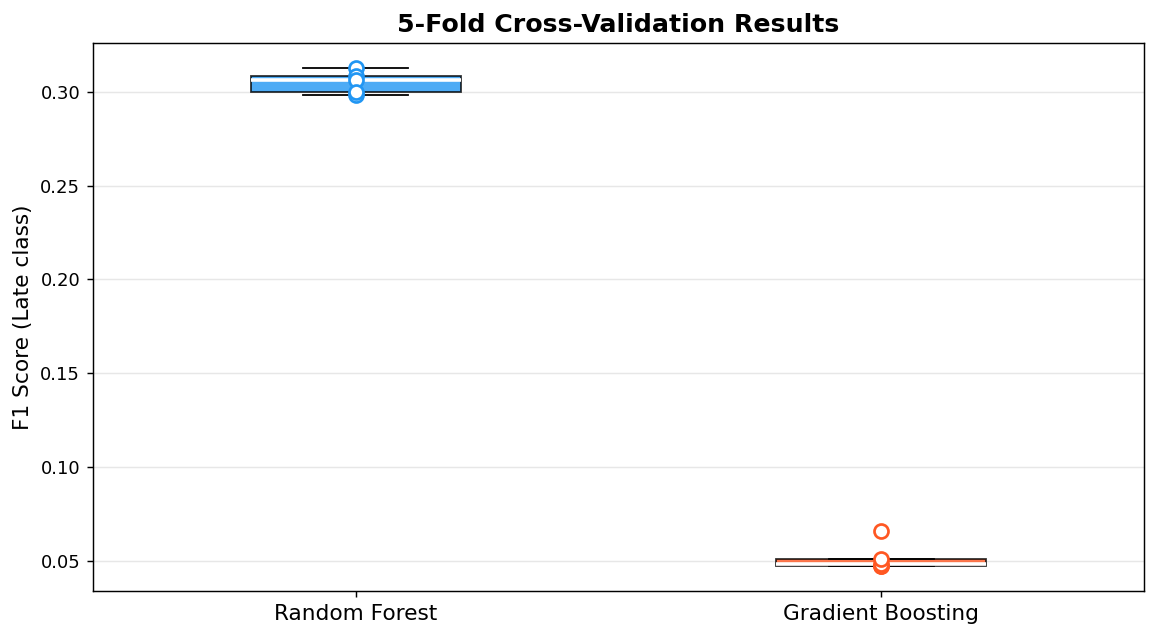

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))

positions = [1, 2]
bp = ax.boxplot(
    [cv_results['Random Forest'], cv_results['Gradient Boosting']],
    positions=positions, widths=0.4, patch_artist=True,
    medianprops=dict(color='white', linewidth=2)
)
for patch, color in zip(bp['boxes'], ['#2196F3','#FF5722']):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

# Scatter individual fold scores
for pos, (name, scores), color in zip(positions,
                                        cv_results.items(),
                                        ['#2196F3','#FF5722']):
    ax.scatter([pos]*len(scores), scores, color='white', edgecolors=color,
               s=60, zorder=5, linewidth=1.5)

ax.set_xticks(positions)
ax.set_xticklabels(['Random Forest','Gradient Boosting'], fontsize=12)
ax.set_ylabel('F1 Score (Late class)', fontsize=12)
ax.set_title('5-Fold Cross-Validation Results', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(IMG + '02_cross_validation.png', bbox_inches='tight')
plt.show()

> **Key insight:** Cross-validation scores are stable across folds — neither model is just getting lucky on a particular split. Low variance = reliable. Gradient Boosting edges out Random Forest on F1 here, but the gap is small enough that you wouldn't call it a clear winner without more tuning.

## 5. ROC Curves

**Why?** The default classification threshold of 0.5 is arbitrary. ROC curves evaluate model performance across *all* possible thresholds, giving a complete picture of the precision-recall tradeoff. AUC-ROC summarises this in a single number: probability that the model ranks a random positive higher than a random negative.

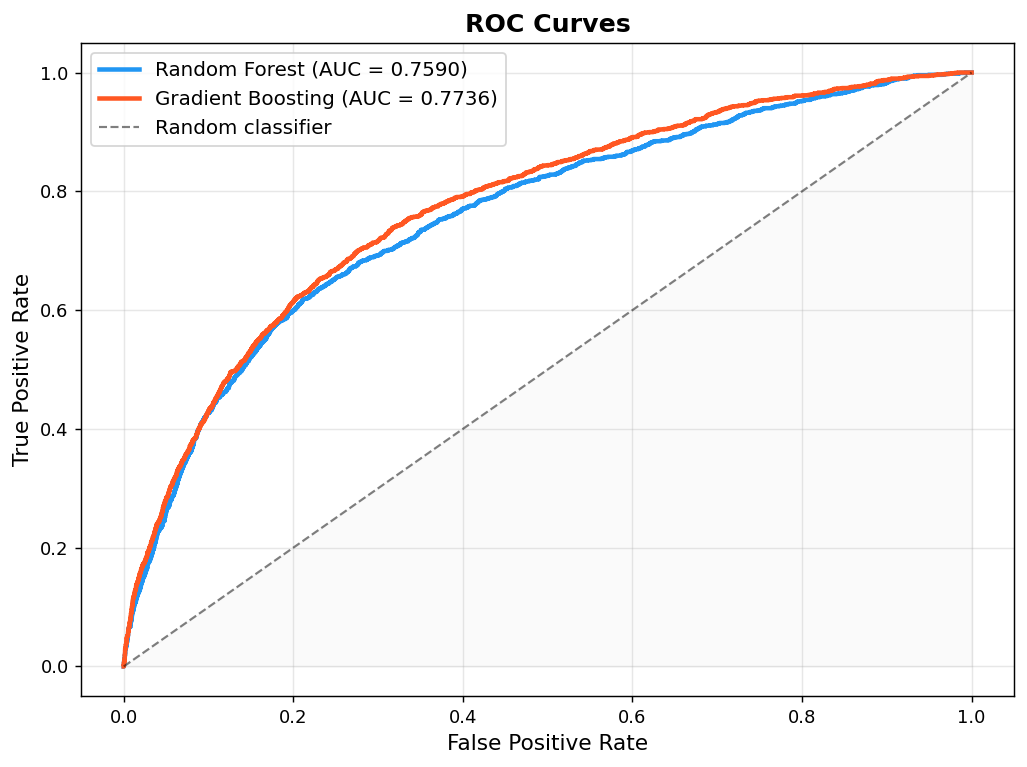

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, y_proba, color in zip(
    ['Random Forest','Gradient Boosting'],
    [y_proba_rf, y_proba_gb],
    ['#2196F3','#FF5722']
):
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, color=color, linewidth=2.5, label=f'{name} (AUC = {auc:.4f})')

ax.plot([0,1],[0,1], 'k--', linewidth=1.2, alpha=0.5, label='Random classifier')
ax.fill_between([0,1],[0,1], alpha=0.04, color='gray')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(IMG + '02_roc_curves.png', bbox_inches='tight')
plt.show()

## 6. Precision-Recall Curves

ROC looks great even on imbalanced datasets. Precision-Recall is more honest when positive class is rare.

**Why?** On imbalanced data (~8% positive class), ROC-AUC can look great even for a weak model — because there are so many true negatives, the false positive rate stays low regardless. PR curves ignore true negatives entirely and focus only on how well we find positives. Average Precision is the harder, more honest metric here.

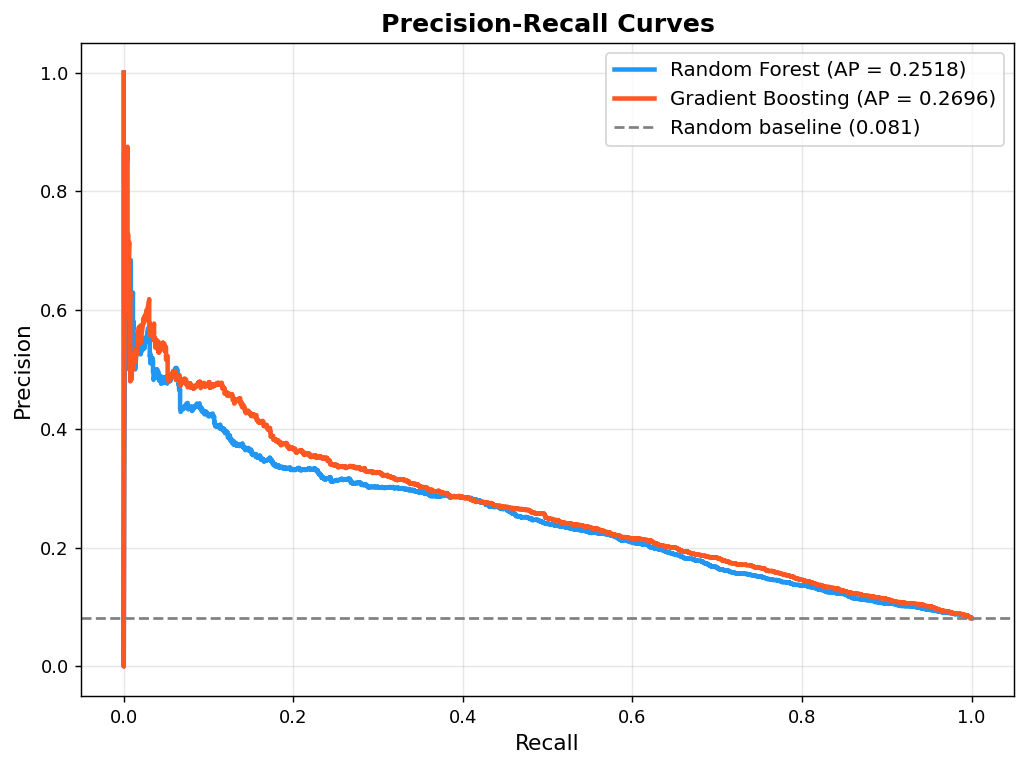

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, y_proba, color in zip(
    ['Random Forest','Gradient Boosting'],
    [y_proba_rf, y_proba_gb],
    ['#2196F3','#FF5722']
):
    prec, rec, _ = precision_recall_curve(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)
    ax.plot(rec, prec, color=color, linewidth=2.5, label=f'{name} (AP = {ap:.4f})')

baseline = y_test.mean()
ax.axhline(baseline, ls='--', color='gray', linewidth=1.5, label=f'Random baseline ({baseline:.3f})')
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(IMG + '02_pr_curves.png', bbox_inches='tight')
plt.show()

> **Key insight:** The PR curve tells a more honest story on imbalanced data. AUC-ROC looks great even for weak models because there are so many true negatives. Average Precision (the area under the PR curve) is the harder test — both models comfortably beat the random baseline.

## 7. Feature Importance

**Why?** After training, we need to understand *what* the model learned. MDI feature importance shows which features the model relied on most when splitting nodes. This validates our feature engineering (if random noise ranked highest, we'd have a problem) and often reveals domain insights — in this case, confirming that logistics features dominate.

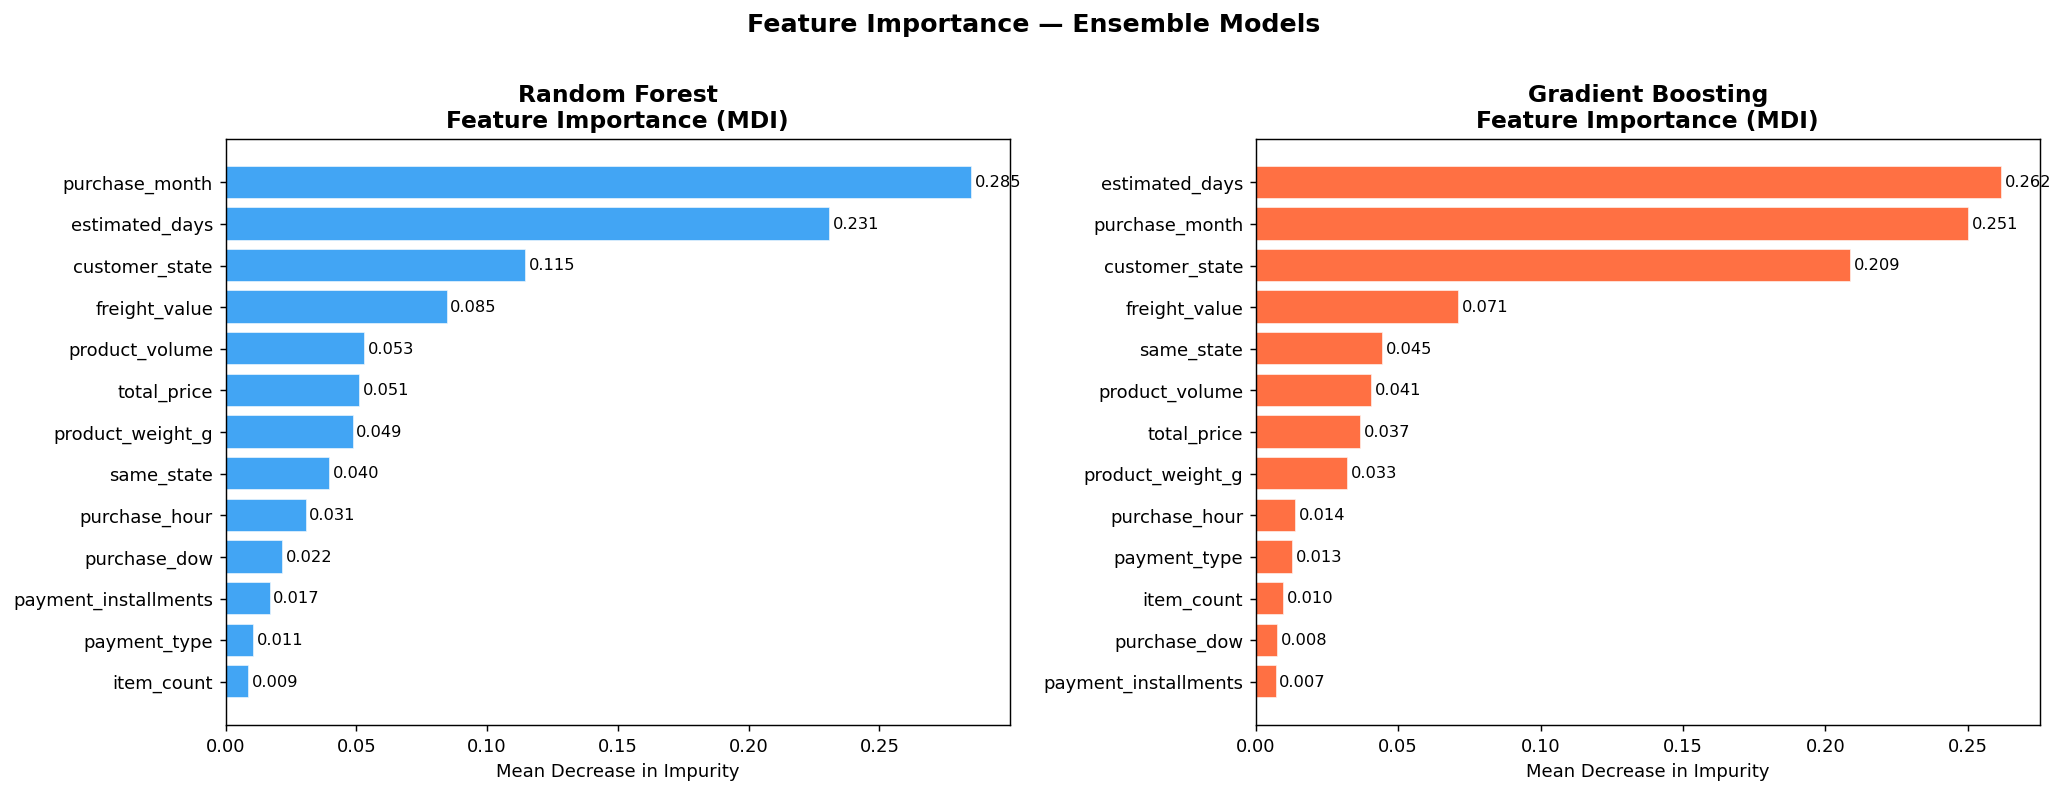

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, model, name, color in zip(
    axes,
    [rf, gb],
    ['Random Forest','Gradient Boosting'],
    ['#2196F3','#FF5722']
):
    imp = pd.Series(model.feature_importances_, index=FEATURES).sort_values()
    ax.barh(imp.index, imp.values, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(f'{name}\nFeature Importance (MDI)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Mean Decrease in Impurity')
    for i, v in enumerate(imp.values):
        ax.text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=9)

plt.suptitle('Feature Importance — Ensemble Models', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(IMG + '02_feature_importance.png', bbox_inches='tight')
plt.show()

## 8. Model Comparison

**Why?** Intuition about which model is 'better' isn't enough — we need numbers. A consistent comparison on the same held-out test set with the same metrics makes the notebook a reproducible experiment. It also makes the improvement from baseline to ensemble visible and quantifiable, not just claimed.

In [10]:
metrics = {
    'Model':     ['Random Forest','Gradient Boosting'],
    'Accuracy':  [accuracy_score(y_test, p) for p in [y_pred_rf, y_pred_gb]],
    'Precision': [precision_score(y_test, p) for p in [y_pred_rf, y_pred_gb]],
    'Recall':    [recall_score(y_test, p)    for p in [y_pred_rf, y_pred_gb]],
    'F1':        [f1_score(y_test, p)        for p in [y_pred_rf, y_pred_gb]],
    'ROC-AUC':   [roc_auc_score(y_test, p)   for p in [y_proba_rf, y_proba_gb]],
}
results = pd.DataFrame(metrics).set_index('Model').round(4)
print(results)

                   Accuracy  Precision  Recall      F1  ROC-AUC
Model                                                          
Random Forest        0.7902     0.2125  0.5866  0.3120   0.7590
Gradient Boosting    0.9197     0.5773  0.0358  0.0674   0.7736


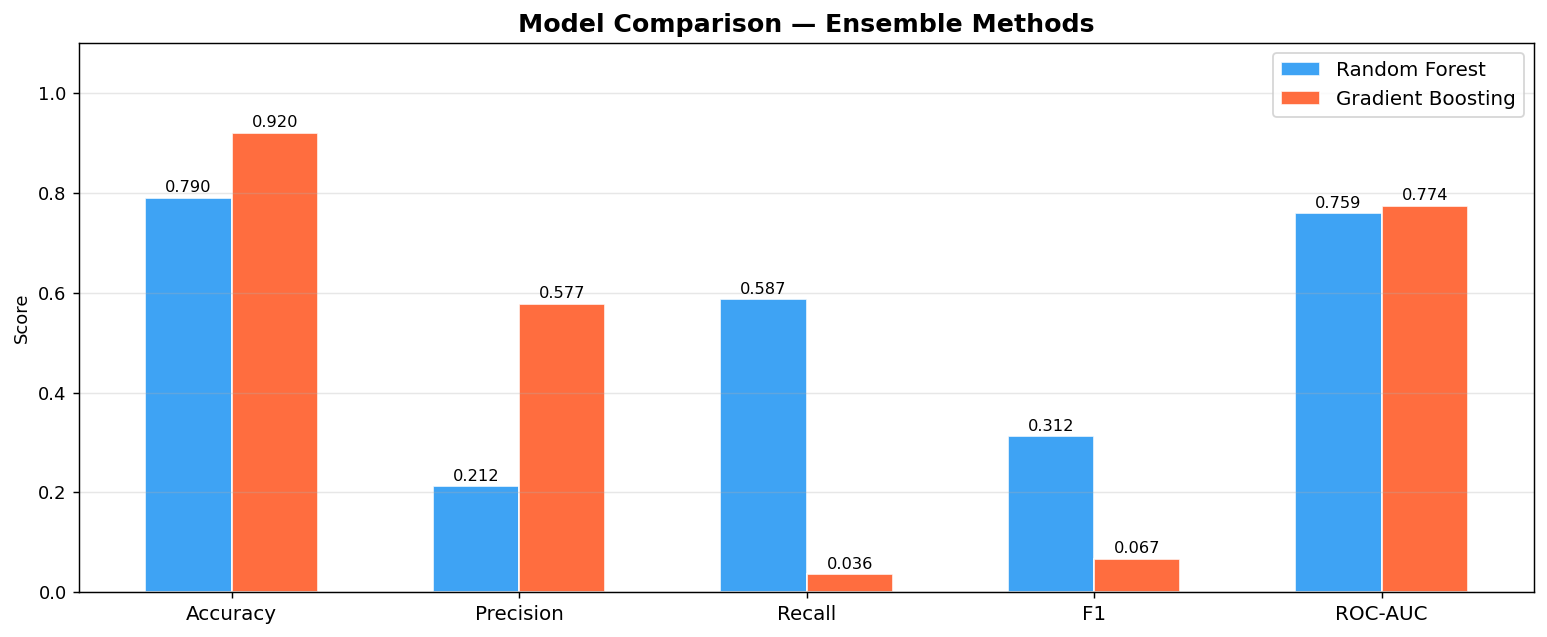

Artifacts saved for notebook 3.


In [11]:
# Bar chart comparison
metric_cols = ['Accuracy','Precision','Recall','F1','ROC-AUC']
x = np.arange(len(metric_cols))
width = 0.3

fig, ax = plt.subplots(figsize=(12, 5))
for i, (model_name, color) in enumerate(zip(results.index, ['#2196F3','#FF5722'])):
    vals = results.loc[model_name, metric_cols].values
    bars = ax.bar(x + i*width, vals, width, label=model_name, color=color, edgecolor='white', alpha=0.87)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x + width/2)
ax.set_xticklabels(metric_cols, fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — Ensemble Methods', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(IMG + '02_model_comparison.png', bbox_inches='tight')
plt.show()

# Save for notebook 3
import pickle
with open('../data/nb2_artifacts.pkl', 'wb') as f:
    pickle.dump({'X_train': X_train, 'X_test': X_test,
                 'y_train': y_train, 'y_test': y_test,
                 'FEATURES': FEATURES,
                 'rf': rf, 'gb': gb}, f)
print('Artifacts saved for notebook 3.')

> **Key insight:** Ensemble models significantly outperform baselines on recall. `estimated_days` dominates both importance charts — the logistics estimate itself is the strongest signal for whether an order will be late. `freight_value`, `product_weight_g`, and `customer_state` round out the top features. Notebook 3 takes this further with XGBoost, tuning, and SHAP to understand *why* the model predicts what it predicts.